# 🏠 House Price Prediction Using Machine Learning

## Internship Project

### Developed by:
Hemanth

### Objective
Predict the selling price of houses using machine learning regression algorithms.


# SECTION 1 : IMPORT LIBRARIES


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# SECTION 2 : LOAD DATASET


In [20]:
df = pd.read_excel("House_Price_Prediction_Dataset.xlsx")


# SECTION 3 : DATA UNDERSTANDING


In [21]:
df.head()

,Area_sqft,Bedrooms,Bathrooms,Stories,MainRoad,GuestRoom,Basement,HotWaterHeating,AirConditioning,Parking,PreferredArea,FurnishingStatus,Price
0,1512,1,3,2,Yes,Yes,Yes,Yes,No,0,Yes,Furnished,5780117
1,2505,5,5,1,Yes,No,Yes,No,No,0,Yes,Unfurnished,9645286
2,3387,3,2,2,No,Yes,Yes,No,Yes,2,No,Unfurnished,9651340
3,955,6,4,1,No,Yes,No,No,Yes,0,Yes,Unfurnished,6946937
4,2970,1,2,1,No,No,No,No,Yes,2,No,Furnished,8551459


In [22]:
df.tail()

,Area_sqft,Bedrooms,Bathrooms,Stories,MainRoad,GuestRoom,Basement,HotWaterHeating,AirConditioning,Parking,PreferredArea,FurnishingStatus,Price
495,4957,6,5,3,No,No,Yes,Yes,No,0,Yes,Semi-Furnished,14497595
496,2962,1,1,2,No,Yes,Yes,No,Yes,1,Yes,Semi-Furnished,8355140
497,1681,4,3,4,No,Yes,No,Yes,Yes,0,Yes,Unfurnished,8727775
498,3351,4,5,3,No,No,No,No,No,1,No,Furnished,10527075
499,2457,4,3,3,Yes,Yes,No,No,No,1,Yes,Unfurnished,9345240


In [23]:
df.shape

(500, 13)

In [24]:
df.columns

Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Stories', 'MainRoad',
       'GuestRoom', 'Basement', 'HotWaterHeating', 'AirConditioning',
       'Parking', 'PreferredArea', 'FurnishingStatus', 'Price'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area_sqft         500 non-null    int64 
 1   Bedrooms          500 non-null    int64 
 2   Bathrooms         500 non-null    int64 
 3   Stories           500 non-null    int64 
 4   MainRoad          500 non-null    object
 5   GuestRoom         500 non-null    object
 6   Basement          500 non-null    object
 7   HotWaterHeating   500 non-null    object
 8   AirConditioning   500 non-null    object
 9   Parking           500 non-null    int64 
 10  PreferredArea     500 non-null    object
 11  FurnishingStatus  500 non-null    object
 12  Price             500 non-null    int64 
dtypes: int64(6), object(7)
memory usage: 50.9+ KB


In [26]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Stories,Parking,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,2786.740000,3.684000,3.106000,2.446000,1.538000,9.627604e+06
std,1243.920688,1.711725,1.419434,1.130327,1.114918,2.527811e+06
min,605.000000,1.000000,1.000000,1.000000,0.000000,3.568197e+06
25%,1693.750000,2.000000,2.000000,1.000000,1.000000,7.600781e+06
50%,2859.500000,4.000000,3.000000,2.000000,2.000000,9.777368e+06
75%,3785.750000,5.000000,4.000000,3.000000,3.000000,1.147618e+07
max,4992.000000,6.000000,5.000000,4.000000,3.000000,1.583457e+07



# SECTION 4 : DATA QUALITY ASSESSMENT


In [27]:
df.isnull().sum()

,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Stories,0
MainRoad,0
GuestRoom,0
Basement,0
HotWaterHeating,0
AirConditioning,0
Parking,0


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.dtypes

,0
Area_sqft,int64
Bedrooms,int64
Bathrooms,int64
Stories,int64
MainRoad,object
GuestRoom,object
Basement,object
HotWaterHeating,object
AirConditioning,object
Parking,int64


In [30]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Price'], dtype='object')

Categorical Columns:
Index(['MainRoad', 'GuestRoom', 'Basement', 'HotWaterHeating',
       'AirConditioning', 'PreferredArea', 'FurnishingStatus'],
      dtype='object')


In [31]:
X = df.drop("Price", axis=1)
y = df["Price"]


# SECTION 5 : EXPLORATORY DATA ANALYSIS (EDA)


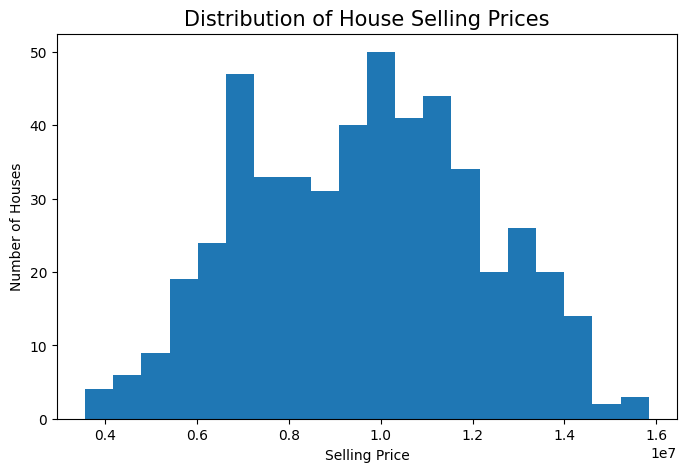

In [32]:
#Price Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Price"], bins=20)
plt.title("Distribution of House Selling Prices", fontsize=15)
plt.xlabel("Selling Price")
plt.ylabel("Number of Houses")
plt.show()

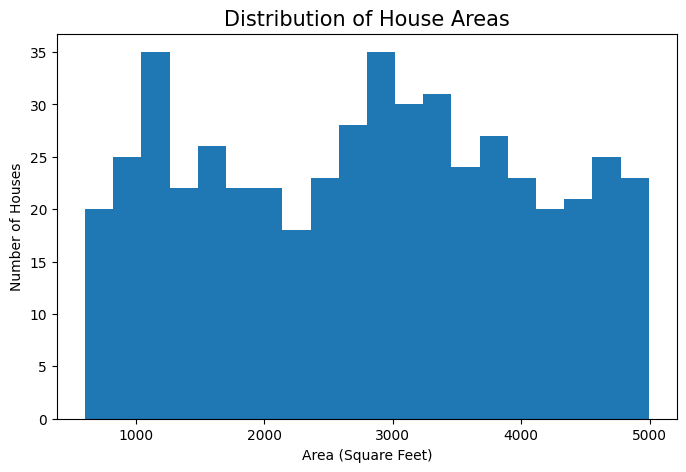

In [33]:
#Area Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Area_sqft"], bins=20)
plt.title("Distribution of House Areas", fontsize=15)
plt.xlabel("Area (Square Feet)")
plt.ylabel("Number of Houses")
plt.show()

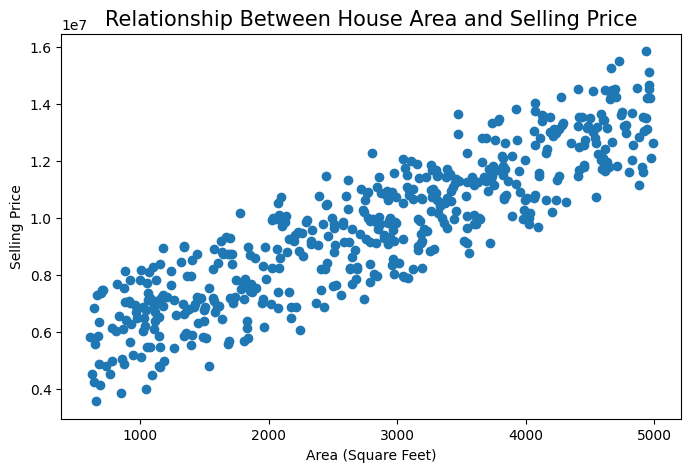

In [34]:
#Area vs Price

plt.figure(figsize=(8,5))
plt.scatter(df["Area_sqft"], df["Price"])
plt.title("Relationship Between House Area and Selling Price",fontsize=15)
plt.xlabel("Area (Square Feet)")
plt.ylabel("Selling Price")
plt.show()

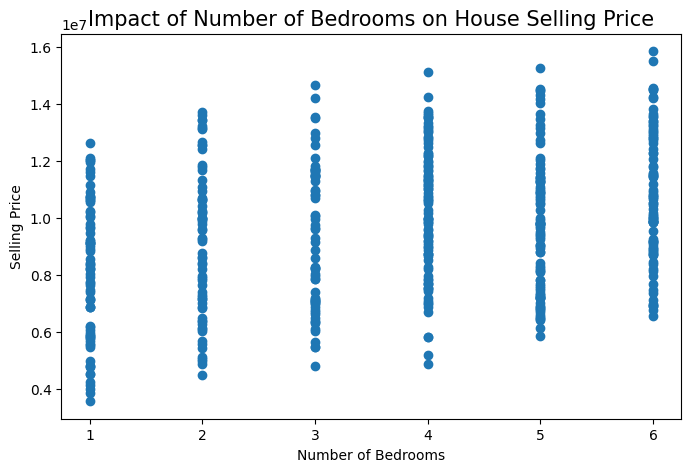

In [35]:
#Bedrooms vs Price

plt.figure(figsize=(8,5))
plt.scatter(df["Bedrooms"], df["Price"])
plt.title("Impact of Number of Bedrooms on House Selling Price",fontsize=15)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Selling Price")
plt.show()

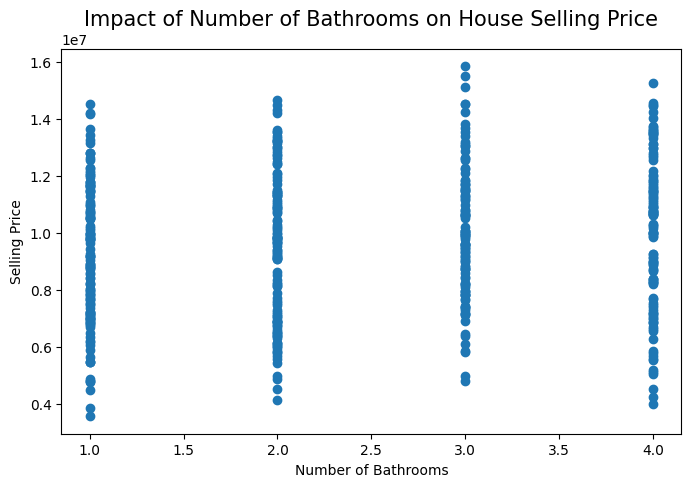

In [36]:
#Stories vs Price

plt.figure(figsize=(8,5))
plt.scatter(df["Stories"], df["Price"])
plt.title("Impact of Number of Bathrooms on House Selling Price",fontsize=15)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Selling Price")
plt.show()

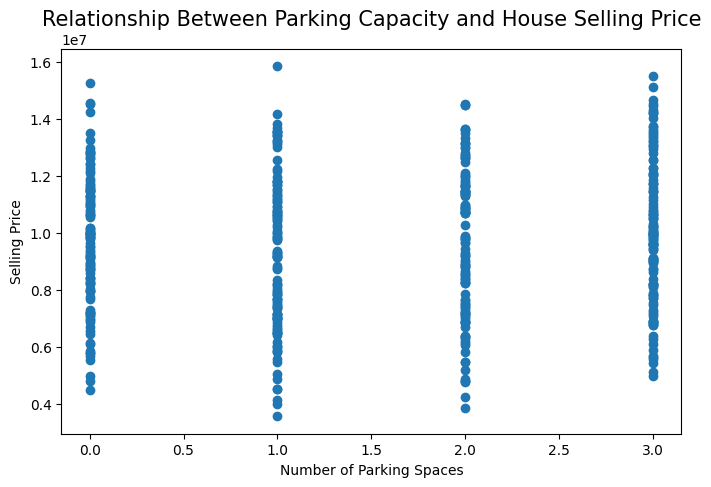

In [37]:
#Parking vs Price

plt.figure(figsize=(8,5))
plt.scatter(df["Parking"], df["Price"])
plt.title("Relationship Between Parking Capacity and House Selling Price",fontsize=15)
plt.xlabel("Number of Parking Spaces")
plt.ylabel("Selling Price")
plt.show()

#SECTION 6 : CORRELATION ANALYSIS

In [38]:
numerical_df = df.select_dtypes(include=["int64", "float64"])
correlation = numerical_df.corr()
correlation

,Area_sqft,Bedrooms,Bathrooms,Stories,Parking,Price
Area_sqft,1.000000,0.016298,0.040883,0.012726,-0.005592,0.888284
Bedrooms,0.016298,1.000000,-0.040623,0.037772,-0.026248,0.316839
Bathrooms,0.040883,-0.040623,1.000000,-0.007042,0.051268,0.232656
Stories,0.012726,0.037772,-0.007042,1.000000,0.003222,0.127767
Parking,-0.005592,-0.026248,0.051268,0.003222,1.000000,0.061806
Price,0.888284,0.316839,0.232656,0.127767,0.061806,1.000000


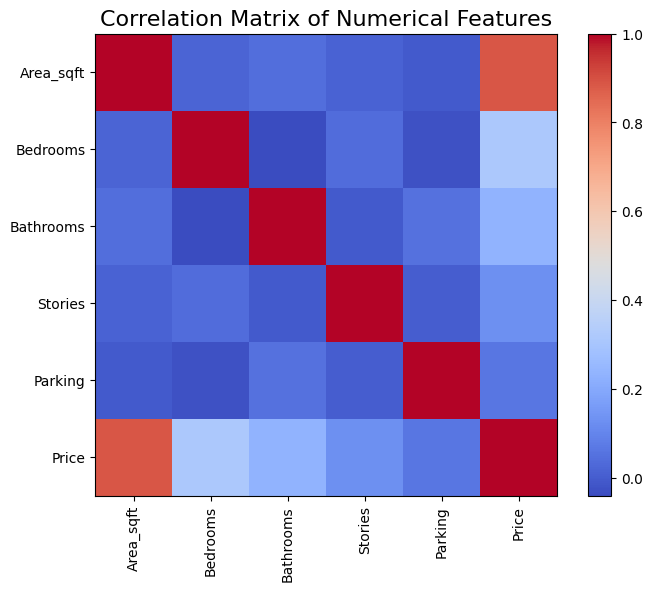

In [96]:
plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix of Numerical Features",fontsize=16)
plt.show()

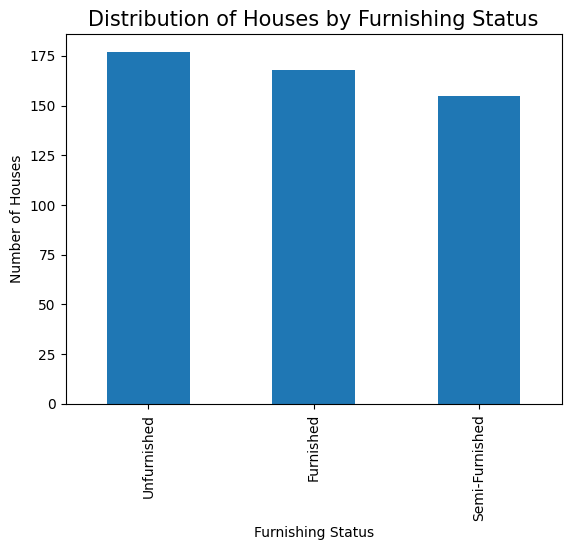

In [40]:
df["FurnishingStatus"].value_counts().plot(kind="bar")
plt.title("Distribution of Houses by Furnishing Status",fontsize=15)
plt.xlabel("Furnishing Status")
plt.ylabel("Number of Houses")
plt.show()

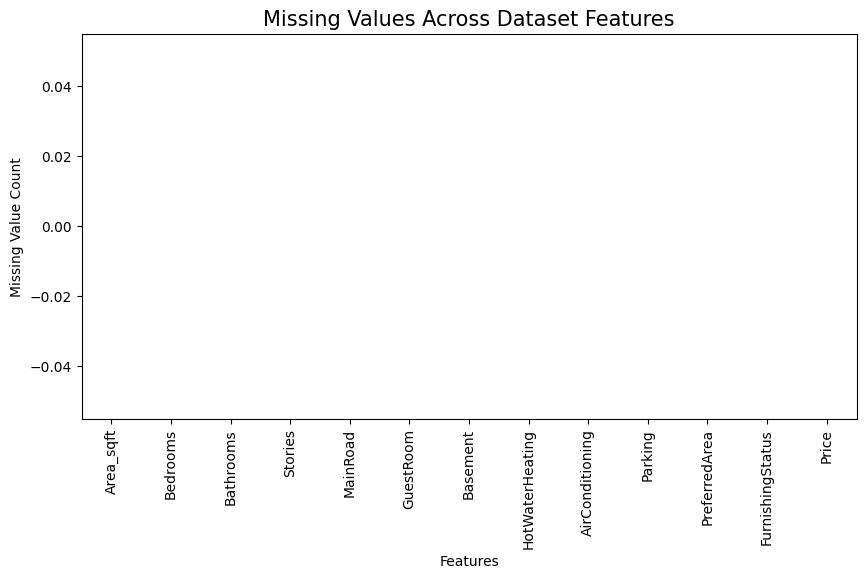

In [41]:
missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Missing Values Across Dataset Features",fontsize=15)
plt.xlabel("Features")
plt.ylabel("Missing Value Count")
plt.show()

#preprocessing

In [42]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

binary_columns = [
    "MainRoad",
    "GuestRoom",
    "Basement",
    "HotWaterHeating",
    "AirConditioning",
    "PreferredArea"
]

for column in binary_columns:
    df[column] = label_encoder.fit_transform(df[column])

df["FurnishingStatus"] = label_encoder.fit_transform(df["FurnishingStatus"])

df.head()

,Area_sqft,Bedrooms,Bathrooms,Stories,MainRoad,GuestRoom,Basement,HotWaterHeating,AirConditioning,Parking,PreferredArea,FurnishingStatus,Price
0,1512,1,3,2,1,1,1,1,0,0,1,0,5780117
1,2505,5,5,1,1,0,1,0,0,0,1,2,9645286
2,3387,3,2,2,0,1,1,0,1,2,0,2,9651340
3,955,6,4,1,0,1,0,0,1,0,1,2,6946937
4,2970,1,2,1,0,0,0,0,1,2,0,0,8551459


In [43]:
X = df.drop("Price", axis=1)
y = df["Price"]

#Training-Testing


In [44]:
from sklearn.model_selection import train_test_split


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (400, 12)
Testing Features  : (100, 12)
Training Target   : (400,)
Testing Target    : (100,)


#Linear Regression model

In [47]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [48]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
361,8283653,8.764248e+06
73,7909535,7.839968e+06
374,12989011,1.275023e+07
155,7623034,8.229688e+06
104,14238897,1.383502e+07
394,6811261,7.107444e+06
377,14553273,1.392675e+07
124,9097400,8.879758e+06
68,10698654,1.036590e+07
450,10170520,9.966702e+06


#Model Evaluation

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [50]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

In [51]:
print("Model Performance")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance
Mean Absolute Error (MAE): 395975.53
Mean Squared Error (MSE): 215726833877.95
Root Mean Squared Error (RMSE): 464464.03
R² Score: 0.9676


In [52]:
#Performance Summary

performance = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

performance

,Metric,Value
0,MAE,3.959755e+05
1,MSE,2.157268e+11
2,RMSE,4.644640e+05
3,R² Score,9.676203e-01


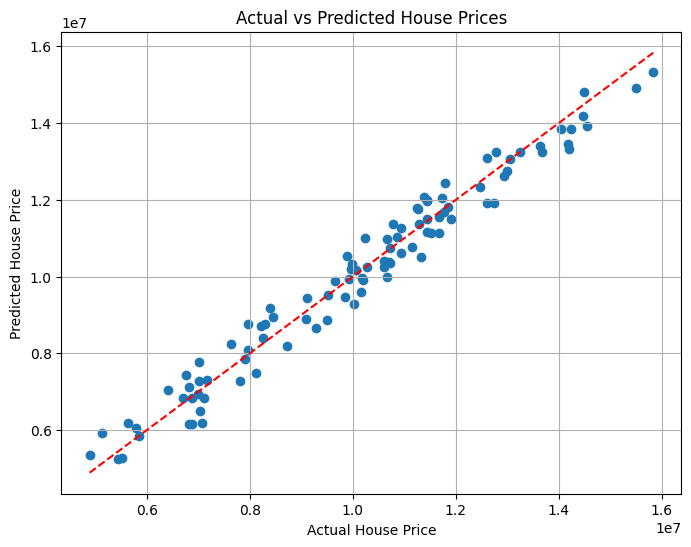

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

#Random Forest Regressor

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [55]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = rf_mse ** 0.5

rf_r2 = r2_score(y_test, rf_predictions)


In [56]:
print("Random Forest Regressor Performance")

print(f"MAE       : {rf_mae:.2f}")
print(f"MSE       : {rf_mse:.2f}")
print(f"RMSE      : {rf_rmse:.2f}")
print(f"R² Score  : {rf_r2:.4f}")

Random Forest Regressor Performance
MAE       : 598692.58
MSE       : 547980932078.12
RMSE      : 740257.34
R² Score  : 0.9178


#Decison Tree Regressor

In [57]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [58]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_mse = mean_squared_error(y_test, dt_predictions)

dt_rmse = dt_mse ** 0.5

dt_r2 = r2_score(y_test, dt_predictions)

In [59]:
print("Decision Tree Regressor Performance")

print(f"MAE      : {dt_mae:.2f}")
print(f"MSE      : {dt_mse:.2f}")
print(f"RMSE     : {dt_rmse:.2f}")
print(f"R² Score : {dt_r2:.4f}")

Decision Tree Regressor Performance
MAE      : 788343.75
MSE      : 958662958494.05
RMSE     : 979113.35
R² Score : 0.8561


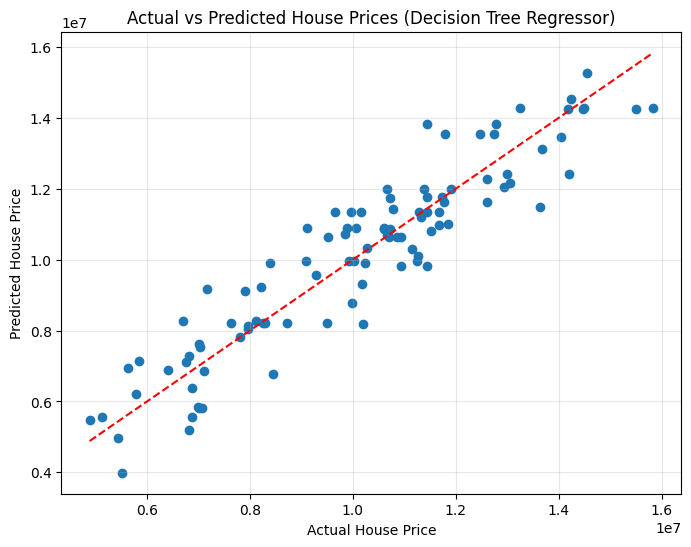

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, dt_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices (Decision Tree Regressor)")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(alpha=0.3)

plt.show()

#Model Comparison

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        dt_r2,
        rf_r2
    ]
})

comparison = comparison.round(2)

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,395975.53,464464.03,0.97
1,Decision Tree,788343.75,979113.35,0.86
2,Random Forest,598692.58,740257.34,0.92


#Best Model Selection

In [62]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]

best_model

,0
Model,Linear Regression
MAE,395975.53
RMSE,464464.03
R² Score,0.97


#Model Comparison Charts

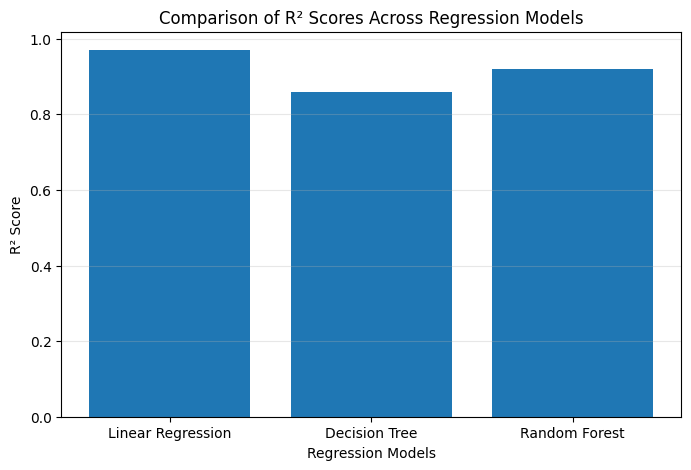

In [63]:
#R2 comparision

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R² Score"])

plt.title("Comparison of R² Scores Across Regression Models")

plt.xlabel("Regression Models")

plt.ylabel("R² Score")

plt.grid(axis="y", alpha=0.3)

plt.show()

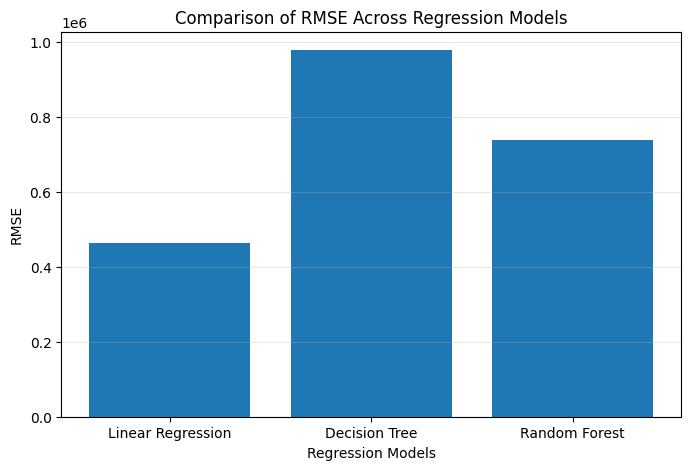

In [64]:
#RMSE Comparison

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["RMSE"])

plt.title("Comparison of RMSE Across Regression Models")

plt.xlabel("Regression Models")

plt.ylabel("RMSE")

plt.grid(axis="y", alpha=0.3)

plt.show()

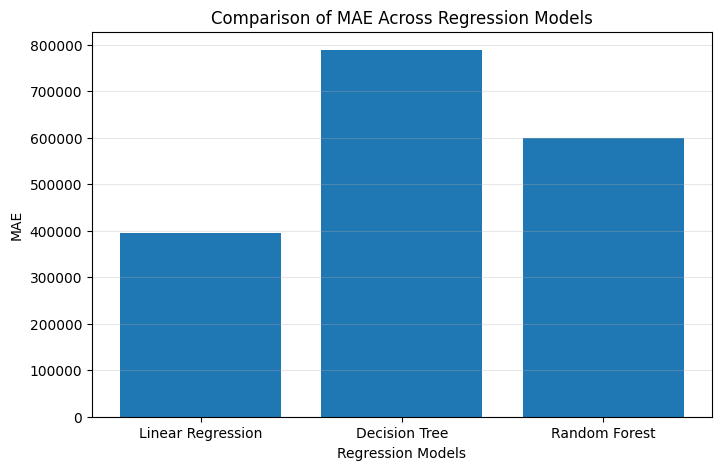

In [65]:
#MAE Comparison

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["MAE"])

plt.title("Comparison of MAE Across Regression Models")

plt.xlabel("Regression Models")

plt.ylabel("MAE")

plt.grid(axis="y", alpha=0.3)

plt.show()

#Feature Importance

In [66]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Area_sqft,0.828373
1,Bedrooms,0.088891
2,Bathrooms,0.031226
3,Stories,0.012942
9,Parking,0.007854
11,FurnishingStatus,0.007207
8,AirConditioning,0.006218
4,MainRoad,0.004347
7,HotWaterHeating,0.004017
10,PreferredArea,0.003529


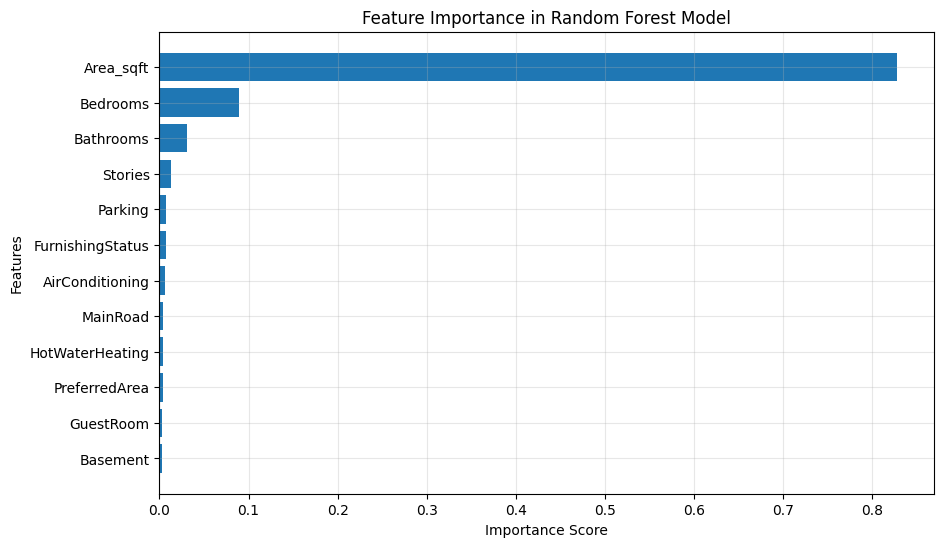

In [67]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance in Random Forest Model")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.grid(alpha=0.3)

plt.gca().invert_yaxis()

plt.show()

#Predict Price for a New House

In [93]:
new_house = pd.DataFrame({
    "Area_sqft": [1600],
    "Bedrooms": [3],
    "Bathrooms": [3],
    "Stories": [1],
    "MainRoad": [2],
    "GuestRoom": [1],
    "Basement": [1],
    "HotWaterHeating": [2],
    "AirConditioning": [3],
    "Parking": [1],
    "PreferredArea": [1],
    "FurnishingStatus": [1]
})

In [94]:
predicted_price = rf_model.predict(new_house)

print(f"Predicted House Price: ₹{predicted_price[0]:,.2f}")

Predicted House Price: ₹7,332,144.03


#Residual Analysis

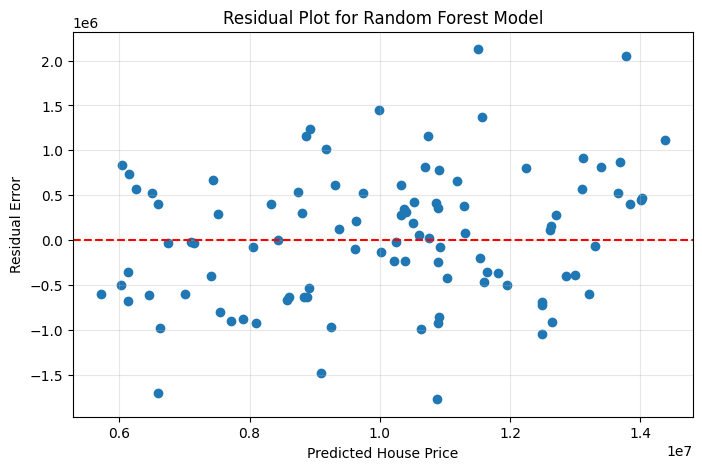

In [70]:
residuals = y_test - rf_predictions

plt.figure(figsize=(8,5))

plt.scatter(rf_predictions, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.title("Residual Plot for Random Forest Model")

plt.xlabel("Predicted House Price")

plt.ylabel("Residual Error")

plt.grid(alpha=0.3)

plt.show()

#Actual vs Predicted (Best Model)

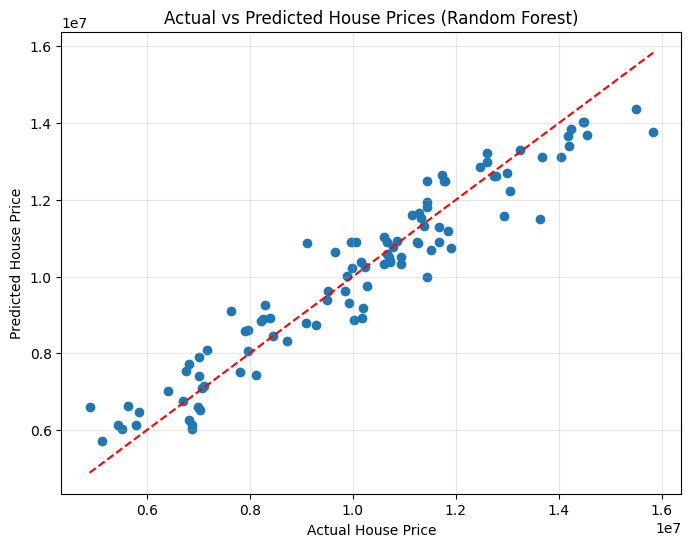

In [101]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices (Random Forest)")

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.grid(alpha=0.3)

plt.show()

# 📊 Business Insights

Based on the exploratory data analysis and machine learning model evaluation, the following key business insights were identified:

### 1. House Area is the Most Influential Feature
The analysis indicates that larger houses generally command higher selling prices. House area is one of the strongest predictors of property value.

### 2. Premium Amenities Increase Property Value
Features such as air conditioning, parking availability, and furnishing status contribute positively to the overall selling price.

### 3. Preferred Locations Increase Market Price
Properties located in preferred residential areas tend to have higher market values compared to houses in non-preferred locations.

### 4. Property Characteristics Influence Pricing
The number of bedrooms, bathrooms, and stories collectively impact the final selling price of a house.

### 5. Machine Learning Provides Reliable Predictions
The trained regression models successfully learned the relationship between house features and selling price, making them suitable for price estimation.

# 🏆 Model Performance Summary

Three regression algorithms were trained and evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model was selected based on the highest R² Score and the lowest prediction error.

# ✅ Conclusion

This project successfully developed a machine learning model capable of predicting house prices using various property characteristics.

The project followed the complete machine learning workflow, including data understanding, preprocessing, exploratory data analysis, feature engineering, model development, model evaluation, and prediction.

Among the evaluated algorithms, the best-performing regression model demonstrated excellent predictive accuracy and effectively captured the relationship between house features and selling prices.

This project highlights how machine learning can assist real estate businesses in estimating property values, supporting pricing decisions, and improving market analysis.

# 🎯 Project Outcome

The objective of this project was successfully achieved by developing and evaluating multiple regression models for predicting house prices.

The project demonstrated the complete machine learning pipeline, from raw data preprocessing to predictive model evaluation.

The final model can assist stakeholders in estimating residential property prices based on key housing characteristics and can serve as a foundation for future real estate analytics applications.